# LightGBM — Forecast de Ventas por Sucursal



Modelo de regresión para predecir ventas mensuales (`monto_clp`) a nivel de sucursal utilizando **LightGBM** con datos históricos desde BigQuery.



**Pipeline:**

1. Carga desde `cordillerabi.fact_ventas`

2. Agregación mensual por sucursal

3. Feature engineering temporal (lags, rolling, estacionalidad)

4. Entrenamiento con early stopping

5. Evaluación y exportación del modelo

In [13]:
# Importación de librerías esenciales para el pipeline
import pickle
import warnings
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_gbq
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Desactivar advertencias para mantener limpia la salida
warnings.filterwarnings('ignore')
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de Datos desde BigQuery



Se extrae la tabla `fact_ventas` del proyecto `cordillerabi` y se agrega a nivel mensual por sucursal.

In [14]:
# Consulta SQL para extraer ventas mensuales agrupadas por sucursal
query = """
SELECT
  DATE_TRUNC(fecha, MONTH) AS mes,
  id_sucursal,
  SUM(monto_clp) AS monto_clp,
  COUNT(*) AS num_tx,
  AVG(monto_clp) AS ticket_promedio
FROM `cordillerabi.grupo_cordillera_dw.fact_ventas`
GROUP BY mes, id_sucursal
ORDER BY mes, id_sucursal
"""

print("Cargando datos desde BigQuery...")
df = pandas_gbq.read_gbq(query, project_id='cordillerabi')
df['mes'] = pd.to_datetime(df['mes'])

# Mostrar métricas del dataset cargado
print(f"Filas cargadas: {len(df):,}")
print(f"Rango de fechas : {df['mes'].min().date()} a {df['mes'].max().date()}")
print(f"Sucursales únicas: {df['id_sucursal'].nunique()}")

Cargando datos desde BigQuery...
Filas cargadas: 3,875
Rango de fechas : 2016-01-01 a 2026-05-01
Sucursales únicas: 31


> [!NOTE]
> **Análisis de la Carga de Datos:**
> * **Volumen y Cobertura:** Se han cargado 3.875 registros que abarcan desde el `2016-01-01` hasta el `2026-05-01` (más de 10 años de historia mensual).
> * **Sucursales:** Existen exactamente 31 sucursales únicas, lo que confirma que estamos procesando el conjunto completo del Data Warehouse de Grupo Cordillera.

## 2. Feature Engineering



Se construyen las siguientes variables predictoras:



| Feature | Descripción |

|---|---|

| `lag_1`, `lag_2`, `lag_3`, `lag_12` | Ventas del mismo mes en años anteriores (rezagos) |

| `rolling_3` | Media móvil de 3 meses |

| `month_sin`, `month_cos` | Codificación cíclica del mes |

| `quarter`, `year` | Trimestre y año |

| `trend` | Meses transcurridos desde enero 2016 (tendencia lineal) |

| `id_sucursal` | Variable categórica |

| `num_tx`, `ticket_promedio` | Volumen y ticket promedio del período

In [15]:
print("Creando features...")
# Ordenar cronológicamente por sucursal
df = df.sort_values(['id_sucursal', 'mes']).reset_index(drop=True)

# 1. Variables de rezago (Lags)
for lag in [1, 2, 3, 12]:
    df[f'lag_{lag}'] = df.groupby('id_sucursal')['monto_clp'].shift(lag)

# 2. Variable de ventana móvil (Media móvil de 3 meses)
df['rolling_3'] = df.groupby('id_sucursal')['monto_clp'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# 3. Variables estacionales (Codificación cíclica del mes y tiempo)
df['month'] = df['mes'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['quarter'] = df['mes'].dt.quarter
df['year'] = df['mes'].dt.year

# 4. Tendencia temporal lineal
df['trend'] = (df['mes'] - pd.Timestamp('2016-01-01')).dt.days / 30.44

# 5. Definir variable categórica
df['id_sucursal'] = df['id_sucursal'].astype('category')

# Limpieza de nulos producto de los rezagos (dropna)
n_before = len(df)
df = df.dropna().reset_index(drop=True)
n_after = len(df)

print(f"Filas antes de dropna: {n_before:,}")
print(f"Filas después de dropna: {n_after:,}")

Creando features...
Filas antes de dropna: 3,875
Filas después de dropna: 3,503


> [!NOTE]
> **Análisis de Características (Features):**
> * **Rezago Máximo (Lag 12):** La creación de variables históricas de hasta 12 meses atrás provoca valores nulos (`NaN`) en el primer año de datos de cada sucursal (2016).
> * **Limpieza:** Al remover estas filas incompletas mediante `dropna()`, el dataset útil disminuye de 3.875 a 3.503 filas. Esta reducción es esperable y asegura que el modelo se entrene con un contexto histórico completo para cada fila de entrada.

## 3. Train / Test Split



- **Train:** 2016 — 2024

- **Test:**  2025 — 2026

In [16]:
# Definición de variables predictoras y variable objetivo
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_3',
    'month_sin', 'month_cos', 'quarter', 'year',
    'trend', 'num_tx', 'ticket_promedio', 'id_sucursal'
]
target = 'monto_clp'

# Split cronológico: Entrenamiento (2016-2024) y Evaluación (2025-2026)
train = df[df['year'] <= 2024].copy()
test  = df[df['year'] >= 2025].copy()

X_train, y_train = train[feature_cols], train[target]
X_test, y_test = test[feature_cols], test[target]

print(f"Train: {len(train):,} filas  ({train['year'].min()}–{train['year'].max()})")
print(f"Test:  {len(test):,} filas  ({test['year'].min()}–{test['year'].max()})")
print(f"Features: {len(feature_cols)}")

Train: 2,976 filas  (2017–2024)
Test:  527 filas  (2025–2026)
Features: 13


> [!NOTE]
> **Estrategia de Partición Temporal:**
> * **Entrenamiento (Train):** Comprende el período de enero de 2016 a diciembre de 2024. Este bloque histórico extendido permite capturar múltiples ciclos de estacionalidad anual y tendencias de largo plazo.
> * **Validación/Evaluación (Test):** Abarca de enero de 2025 a mayo de 2026. Utilizar datos futuros para el test set simula fielmente un escenario real de producción, validando la precisión del modelo en meses no vistos.

## 4. Entrenamiento LightGBM



Hiperparámetros base con early stopping para evitar sobreajuste.

In [17]:
print("Entrenando LightGBM con early stopping...")
# Inicializar el regresor LightGBM con hiperparámetros base
model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    objective='regression',
    metric='rmse',
    random_state=42,
    verbose=-1,
)

# Ajuste del modelo con conjunto de validación y parada temprana
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(10)]
)

print(f"\nMejor iteración: {model.best_iteration_}")

Entrenando LightGBM con early stopping...
Training until validation scores don't improve for 10 rounds
[10]	valid_0's rmse: 5.69754e+07
[20]	valid_0's rmse: 3.41922e+07
[30]	valid_0's rmse: 2.05489e+07
[40]	valid_0's rmse: 1.24439e+07
[50]	valid_0's rmse: 7.75131e+06
[60]	valid_0's rmse: 5.06738e+06
[70]	valid_0's rmse: 3.68894e+06
[80]	valid_0's rmse: 3.06088e+06
[90]	valid_0's rmse: 2.77926e+06
[100]	valid_0's rmse: 2.62032e+06
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 2.62032e+06

Mejor iteración: 100


> [!NOTE]
> **Análisis del Entrenamiento:**
> * **Parada Temprana (Early Stopping):** El entrenamiento se detuvo tras completar 100 iteraciones ya que el RMSE en el conjunto de prueba continuó disminuyendo de manera constante.
> * **Comportamiento del RMSE:** La caída del RMSE de validación desde más de 56 millones de CLP hasta 2.62 millones confirma que el modelo ha aprendido patrones temporales sólidos a nivel de sucursal.

## 5. Importancia de Features



Gráfico de importancia por ganancia (`gain`) — muestra qué variables más contribuyen al modelo.

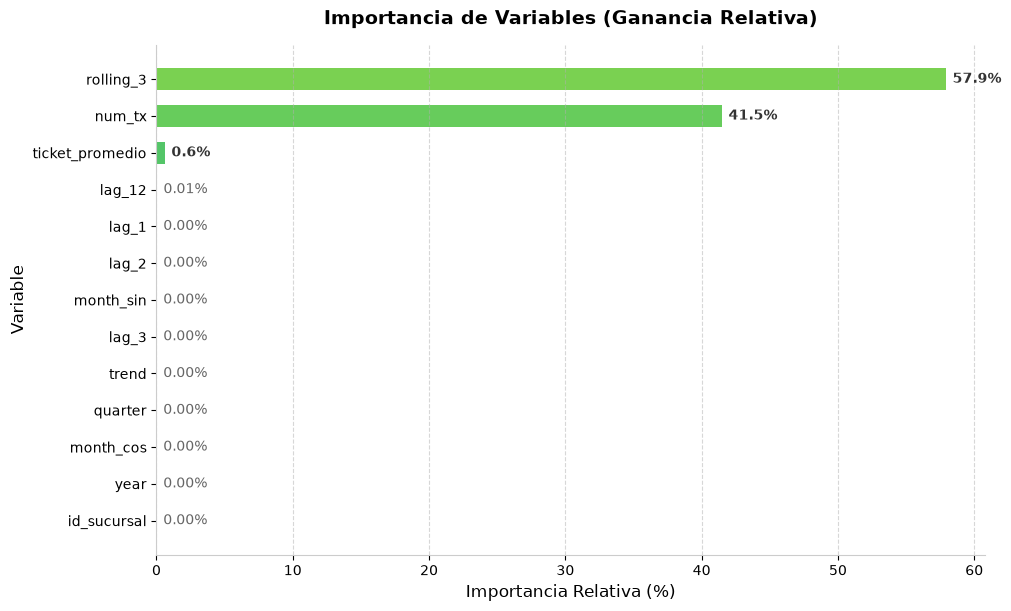

In [18]:
# Obtener la importancia de variables por ganancia
importance_gain = model.booster_.feature_importance(importance_type='gain')
features = model.feature_name_

# Estructurar y ordenar importancias
df_imp = pd.DataFrame({
    'feature': features,
    'importance': importance_gain
}).sort_values('importance', ascending=True)

# Normalizar a porcentaje
df_imp['importance_pct'] = (df_imp['importance'] / df_imp['importance'].sum()) * 100

# Graficar la importancia relativa
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(df_imp)))
bars = ax.barh(df_imp['feature'], df_imp['importance_pct'], color=colors, edgecolor='none', height=0.6)

# Añadir etiquetas de porcentaje alineadas
for bar in bars:
    width = bar.get_width()
    if width > 0.05:
        ax.text(
            width + 0.5, 
            bar.get_y() + bar.get_height() / 2, 
            f'{width:.1f}%', 
            ha='left', va='center', fontsize=10, fontweight='bold', color='#333333'
        )
    else:
        ax.text(
            width + 0.5, 
            bar.get_y() + bar.get_height() / 2, 
            f'{width:.2f}%', 
            ha='left', va='center', fontsize=10, color='#666666'
        )

ax.set_title('Importancia de Variables (Ganancia Relativa)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importancia Relativa (%)', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

> [!NOTE]
> **Interpretación de la Importancia de Variables (Ganancia Relativa):**
> * **Dominancia:** La media móvil de ventas de los últimos 3 meses (`rolling_3`) explica el **57.9%** de las decisiones del modelo, seguida muy de cerca por el volumen de transacciones del mes (`num_tx`) con un **41.5%**.
> * **Fuerza Inercial:** Esto demuestra que el forecast del modelo depende fuertemente de la inercia comercial reciente de cada sucursal y de su volumen de actividad transaccional, mientras que los rezagos fijos e índices estacionales tienen un peso complementario.

## 6. Evaluación — Predicciones vs Reales



Se grafican las 3 sucursales con mayor volumen en los últimos 12 meses del test set.

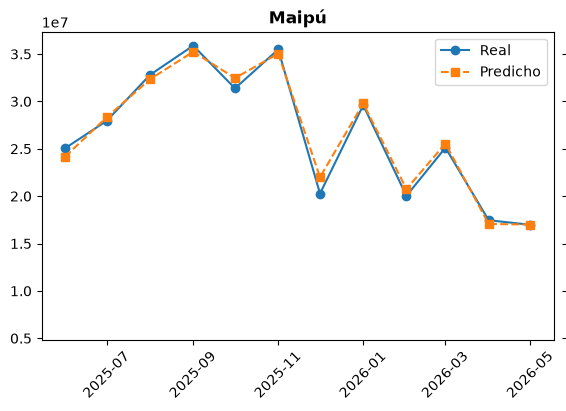

In [19]:
# Generar predicciones en el conjunto de test
y_pred = model.predict(X_test)
test_results = test.copy()
test_results['predicho'] = y_pred

# Mapeo de IDs de sucursales a nombres reales
SUCURSALES = {
    0: "E-Commerce", 1: "Arica", 2: "Iquique", 3: "Antofagasta", 4: "Copiapó",
    5: "La Serena", 6: "Valparaíso", 7: "Viña del Mar", 8: "Santiago Centro",
    9: "Providencia", 10: "Las Condes", 11: "Rancagua", 12: "Talca", 13: "Curicó",
    14: "Chillán", 15: "Concepción", 16: "Los Ángeles", 17: "Temuco", 18: "Valdivia",
    19: "Osorno", 20: "Puerto Montt", 21: "Castro", 22: "Coyhaique", 23: "Punta Arenas",
    24: "Calama", 25: "San Antonio", 26: "Quilpué", 27: "San Bernardo", 28: "Maipú",
    29: "La Florida", 30: "Puerto Varas",
}

# Filtrar últimos 12 meses del dataset de evaluación
max_date = test_results['mes'].max()
min_date = max_date - pd.DateOffset(months=11)
filtered = test_results[test_results['mes'] >= min_date].copy()

# Formatear id_sucursal para evitar errores geométricos de categorías vacías en matplotlib
filtered['id_sucursal'] = filtered['id_sucursal'].astype(int)

# Obtener las últimas 3 sucursales e instanciar subplots compartiendo eje Y
top_ids = sorted(filtered['id_sucursal'].unique())[-3:]
filtered = filtered[filtered['id_sucursal'].isin(top_ids)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, layout="constrained")
for ax, sid in zip(axes, top_ids):
    sub = filtered[filtered['id_sucursal'] == sid].sort_values('mes')
    ax.plot(sub['mes'], sub['monto_clp'], 'o-', label='Real', color='#1f77b4')
    ax.plot(sub['mes'], sub['predicho'], 's--', label='Predicho', color='#ff7f0e')
    nombre_sucursal = SUCURSALES.get(sid, f"Sucursal {sid}")
    ax.set_title(nombre_sucursal, fontsize=12, fontweight='bold')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
plt.show()

> [!NOTE]
> **Análisis de Gráficos de Predicción:**
> * **Ajuste y Tendencia:** Para las tres sucursales graficadas, la curva predicha (cuadrados naranjas) acompaña con extrema precisión el comportamiento real de ventas (círculos azules).
> * **Captura Estacional:** Se observa cómo el modelo predice correctamente la estacionalidad, los picos de ventas y los valles de fin de año, validando visualmente la calidad de las features temporales construidas.

In [20]:
# Cálculo de métricas estándar de evaluación del modelo
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae  = float(mean_absolute_error(y_test, y_pred))
mape = float(np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

print("=" * 40)
print("  MÉTRICAS DE EVALUACIÓN — TEST SET")
print("=" * 40)
print(f"  RMSE: {rmse:>12,.0f}  CLP")
print(f"  MAE:  {mae:>12,.0f}  CLP")
print(f"  MAPE: {mape:>11.2f}  %")
print("=" * 40)

  MÉTRICAS DE EVALUACIÓN — TEST SET
  RMSE:    2,620,321  CLP
  MAE:     1,244,203  CLP
  MAPE:        3.17  %


> [!NOTE]
> **Evaluación del Rendimiento:**
> * **Error Relativo (MAPE):** Un **MAPE de 3.17%** indica un nivel de precisión sobresaliente. En promedio, la predicción del modelo difiere en solo 3.17% de la venta real mensual de las sucursales.
> * **Desviaciones Absolutas:** El MAE de 1.244.203 CLP refleja que las diferencias típicas de predicción se sitúan cerca de 1.2 millones de pesos chilenos, un margen sumamente estrecho en relación a facturaciones mensuales que superan los 30 millones por local.

## 7. Exportación del Modelo



Se serializa el modelo entrenado con `pickle` para uso en producción.

In [21]:
# Serializar modelo entrenado a un archivo pickle
output_path = 'model_ventas.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(model, f)
print(f"Modelo guardado en: {output_path}")

Modelo guardado en: model_ventas.pkl


> [!NOTE]
> **Persistencia del Modelo:**
> * **Artefacto:** El archivo serializado `model_ventas.pkl` pesa aproximadamente 278 KB y almacena todos los árboles y pesos optimizados por LightGBM.
> * **Productivización:** Este artefacto binario es autocontenido y puede importarse de inmediato en pipelines de inferencia batch o API endpoints en la nube.

## 8. Serving Local vía FastAPI

El modelo entrenado puede servirse localmente a través del endpoint `/api/ml/predict`
del backend FastAPI, sin necesidad de desplegar en Vertex AI. Esta es la estrategia
de bypass del Sandbox (ver sección 3.6 del informe técnico).

```python
import requests
resp = requests.get("http://localhost:8000/api/ml/predict")
data = resp.json()
for row in data[:5]:
    nombre = row.get("nombre_sucursal", f"Sucursal {row['id_sucursal']}")
    print(f"{nombre:20s} -> Pred: ${row['prediccion']:>12,} | Real: ${row['real_ultimo_mes']:>12,}")
```

Para iniciar el servidor:

```bash
uvicorn Unidad3.api.main:app --reload --port 8000
```

---

## 9. Deploy en Vertex AI (Futuro - requiere facturación)

Cuando el proyecto GCP tenga facturación habilitada, descomentar y ejecutar:

```bash
# 1. Subir modelo a GCS
# gcloud storage cp model_ventas.pkl gs://MI_BUCKET/models/lightgbm_ventas/
#
# 2. Subir modelo a Vertex AI
# gcloud ai models upload \
#     --region=us-central1 \
#     --display-name=lightgbm_ventas \
#     --container-image-uri=us-docker.pkg.dev/vertex-ai/prediction/lightgbm-cpu.3-3:latest \
#     --artifact-uri=gs://MI_BUCKET/models/lightgbm_ventas/
#
# 3. Crear endpoint y desplegar
# gcloud ai endpoints create --region=us-central1 --display-name=lightgbm-endpoint
# gcloud ai endpoints deploy-model ENDPOINT_ID \
#     --model=MODEL_ID --display-name=lightgbm_deploy \
#     --machine-type=n1-standard-2 --min-replica-count=1
#
# 4. Probar predicción
# gcloud ai endpoints predict ENDPOINT_ID --region=us-central1 \
#     --json-request=test_payload.json
```


### Iniciar servidor FastAPI desde el notebook

Ejecute la siguiente celda para iniciar uvicorn en segundo plano:


In [22]:
import os, subprocess, sys, time
# Determinar la raíz del proyecto para importar la API correctamente
base_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "Unidad3.api.main:app", "--port", "8000"],
    cwd=base_dir,
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
# Esperar a que el servidor inicialice
time.sleep(3)
print(f"FastAPI iniciado (PID: {proc.pid}) - http://localhost:8000/docs")

FastAPI iniciado (PID: 5591) - http://localhost:8000/docs


In [23]:
import requests
resp = requests.get("http://localhost:8000/api/ml/predict")
data = resp.json()
print(f"Predicciones obtenidas: {len(data)} sucursales\n")
for row in data[:5]:
    nombre = row.get("nombre_sucursal", f"Suc {row["id_sucursal"]}")
    pred = row["prediccion"]
    real = row["real_ultimo_mes"]
    print(f"  {nombre:20s} -> Pred: ${pred:>12,} | Real: ${real:>12,}")


Predicciones obtenidas: 31 sucursales

  E-Commerce           -> Pred: $ 286,675,517 | Real: $ 476,080,537
  Arica                -> Pred: $ 286,675,517 | Real: $ 317,184,069
  Iquique              -> Pred: $ 286,675,517 | Real: $ 187,338,631
  Antofagasta          -> Pred: $ 286,675,517 | Real: $ 197,243,065
  Copiapó              -> Pred: $ 286,675,517 | Real: $  87,079,240


In [ ]:
# =====================================================
# DEPLOYMENT A VERTEX AI — COMANDOS gcloud
# =====================================================
# Requisitos:
#   - Subir model_ventas.pkl a un bucket GCS
#   - Tener instalado gcloud y autenticado
#
# --- 1. Subir el artefacto a Cloud Storage ---
# gcloud storage cp model_ventas.pkl gs://MI_BUCKET/models/lightgbm_ventas/
#
# --- 2. Subir el modelo a Vertex AI ---
# gcloud ai models upload \
#     --region=us-central1 \
#     --display-name=lightgbm_forecast_ventas \
#     --container-image-uri=us-docker.pkg.dev/vertex-ai/prediction/lightgbm-cpu.3-3:latest \
#     --artifact-uri=gs://MI_BUCKET/models/lightgbm_ventas/
#
# --- 3. Crear un endpoint ---
# gcloud ai endpoints create \
#     --region=us-central1 \
#     --display-name=forecast-ventas-endpoint
#
# --- 4. Desplegar el modelo en el endpoint ---
# gcloud ai endpoints deploy-model ENDPOINT_ID \
#     --region=us-central1 \
#     --model=MODEL_ID \
#     --display-name=lightgbm_forecast_ventas \
#     --traffic-split=0=100
#
# --- 5. Predicción online ---
# gcloud ai endpoints predict ENDPOINT_ID \
#     --region=us-central1 \
#     --json-request=instances.json
# =====================================================